#**Employee Sentiment Analysis**


### Importing Libraries

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from datetime import datetime, timedelta 


### Loading Dataset

In [4]:
# Load dataset from CSV file
df = pd.read_csv("test.csv")
df["date"] = pd.to_datetime(df["date"])


### Data Cleaning

In [5]:
# Display first few rows of the dataset
df.info()
df.head()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Subject  2191 non-null   object        
 1   body     2191 non-null   object        
 2   date     2191 non-null   datetime64[ns]
 3   from     2191 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 68.6+ KB


,0
Subject,0
body,0
date,0
from,0


In [6]:
# Replaces missing values
df["body"] = df["body"].fillna("No body")
df["from"] = df["from"].fillna("Unknown")
df = df.dropna(subset=["date"]) # Remove rows with missing values


In [7]:
def clean_body(body): # Defining a function to clean th body
    body = str(body)
    body = re.sub(r'=\n', '', body)
    body = re.sub(r'=[0-9A-Fa-f]{2}', ' ', body)
    body = re.sub(r'^>.*$', '', body)
    body = re.sub(r'\s+', ' ', body).strip()
    return body

df["body"] = df["body"].apply(clean_body)


In [8]:
# Display first few rows of the dataset after dropping the duplicate rows
df = df.drop_duplicates()
df.head()


,Subject,body,date,from
0,EnronOptions Update!,EnronOptions Announcement We have updated the ...,2010-05-10,sally.beck@enron.com
1,(No Subject),"Marc, Unfortunately, today is not going to wor...",2010-07-29,eric.bass@enron.com
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com


### Feature Engineering

In [9]:
# creating name column from the email
df["employee_name"] = df["from"].str.split("@").str[0]
df.head()


,Subject,body,date,from,employee_name
0,EnronOptions Update!,EnronOptions Announcement We have updated the ...,2010-05-10,sally.beck@enron.com,sally.beck
1,(No Subject),"Marc, Unfortunately, today is not going to wor...",2010-07-29,eric.bass@enron.com,eric.bass
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com,sally.beck
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com,johnny.palmer
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com,lydia.delgado


### Sentiment Labeling

In [11]:
# Using Huggingface for pre trained models
from transformers import pipeline

df["message"] = df["Subject"] + df["body"]

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment", # RoBERTa model for sentiment analysis
    truncation=True,
    max_length=128,
    device=0
)

texts = df["message"].astype(str).tolist()

results = sentiment_model(texts, batch_size=32)

label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive"
}

df["sentiment"] = [label_map[r["label"]] for r in results]


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
print("Sentiment Labeling Complete!")
print(f"\nDistribution:\n{df['sentiment'].value_counts()}")

Sentiment Labeling Complete!

Distribution:
sentiment
Neutral     1437
Positive     607
Negative     147
Name: count, dtype: int64


### Convert Sentiment to Score

In [13]:
score_map = {
    "Positive": 1,
    "Negative": -1,
    "Neutral": 0
}

df["score"] = df["sentiment"].map(score_map)


#**Exploratory Data Analysis**

In [14]:
# Display the shape, data types and missing values of the dataset
print(f"Dataset Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
df.head()


Dataset Shape: (2191, 8)

Data Types:
Subject                  object
body                     object
date             datetime64[ns]
from                     object
employee_name            object
message                  object
sentiment                object
score                     int64
dtype: object

Missing Values:
Subject          0
body             0
date             0
from             0
employee_name    0
message          0
sentiment        0
score            0
dtype: int64


,Subject,body,date,from,employee_name,message,sentiment,score
0,EnronOptions Update!,EnronOptions Announcement We have updated the ...,2010-05-10,sally.beck@enron.com,sally.beck,EnronOptions Update!EnronOptions Announcement ...,Positive,1
1,(No Subject),"Marc, Unfortunately, today is not going to wor...",2010-07-29,eric.bass@enron.com,eric.bass,"(No Subject)Marc, Unfortunately, today is not ...",Negative,-1
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com,sally.beck,Phone Screen Interview - Shannon L. BurnhamWh...,Neutral,0
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com,johnny.palmer,RE: My new work emailwe were thinking papasito...,Neutral,0
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com,lydia.delgado,BetSince you never gave me the $20 for the las...,Neutral,0


#### Time Features

In [15]:
df["month"] = df["date"].dt.to_period("M") # Extract the month and year from the date column and store it as a monthly period

### Sentiment Distribution

In [16]:
sentiment_counts = df["sentiment"].value_counts() # Count of all Positive, Negative and Neutral sentiments
print(sentiment_counts)

sentiment
Neutral     1437
Positive     607
Negative     147
Name: count, dtype: int64


In [17]:
import os
os.makedirs("visualizations", exist_ok=True)

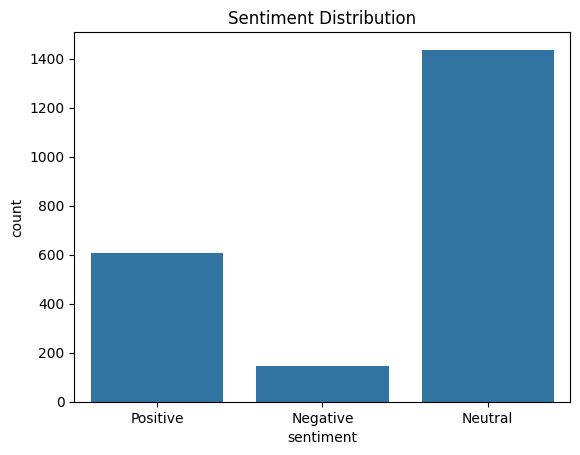

In [18]:
# Create visualization for data analysis
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.savefig("visualizations/sentiment_distribution.png", bbox_inches="tight")
plt.show()


### Messages per Month

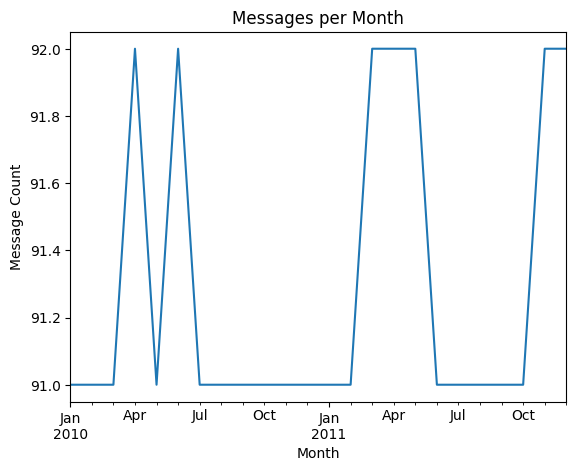

In [19]:
# Create visualization for data analysis
df.groupby("month").size().plot()

plt.title("Messages per Month")
plt.xlabel("Month")
plt.ylabel("Message Count")
plt.savefig("visualizations/messages_per_month.png", bbox_inches="tight")
plt.show()


### Sentiment Trend

In [20]:
monthly_sentiment = df.groupby("month")["score"].sum()
monthly_sentiment

,score
month,
2010-01,18
2010-02,11
2010-03,18
2010-04,18
2010-05,16
2010-06,12
2010-07,12
2010-08,23
2010-09,18


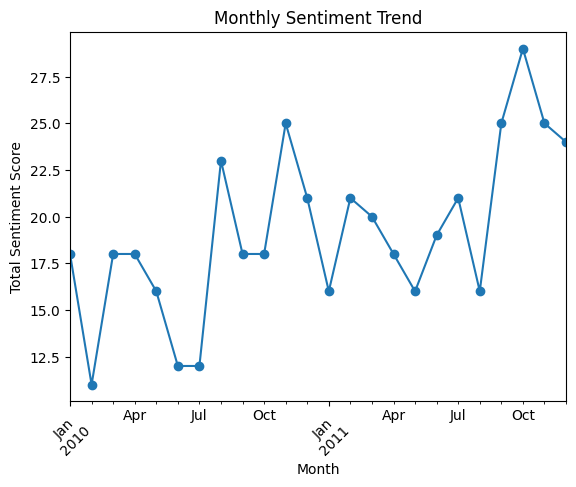

In [21]:
# Create visualization for data analysis
monthly_sentiment.plot(marker="o")

plt.title("Monthly Sentiment Trend")
plt.xlabel("Month")
plt.ylabel("Total Sentiment Score")

plt.xticks(rotation=45)
plt.savefig("visualizations/monthly_sentiment_trend.png", bbox_inches="tight")
plt.show()


### Employee Activity Analysis

In [22]:

df["message_length"] = df["message"].str.len()

employee_activity = df.groupby("employee_name").agg(    # Grouping messages to check emploee activity
total_messages=("message", "count"),
avg_message_length=("message_length", "mean")).reset_index()

employee_activity.head()


,employee_name,total_messages,avg_message_length
0,bobette.riner,217,271.271889
1,don.baughman,213,260.544601
2,eric.bass,210,286.133333
3,john.arnold,256,284.613281
4,johnny.palmer,213,266.882629


### Monthly Sentiment Score

In [23]:

monthly_scores = df.groupby(["employee_name", "month"])["score"].sum().reset_index()
monthly_scores.rename(columns={"score": "monthly_score"}, inplace=True)
monthly_scores.head()


,employee_name,month,monthly_score
0,bobette.riner,2010-01,0
1,bobette.riner,2010-02,4
2,bobette.riner,2010-03,0
3,bobette.riner,2010-04,0
4,bobette.riner,2010-05,2


### **Employee Ranking**
#### Top Positive Employees

In [24]:
# Display top 3 employees with a positive monthly score of the dataset
top_positive = monthly_scores.sort_values(
    ["month", "monthly_score", "employee_name"],
    ascending=[True, False, True]).groupby("month").head(3)

top_positive


,employee_name,month,monthly_score
144,lydia.delgado,2010-01,4
168,patti.thompson,2010-01,4
48,eric.bass,2010-01,3
1,bobette.riner,2010-02,4
25,don.baughman,2010-02,4
...,...,...,...
94,john.arnold,2011-11,4
190,patti.thompson,2011-11,4
143,kayne.coulter,2011-12,5
167,lydia.delgado,2011-12,4


#### Top Negative Employees

In [25]:
# Display top 3 employees with a negative monthly score of the dataset
top_negative = monthly_scores.sort_values(
    ["month", "monthly_score", "employee_name"],
    ascending=[True, True, True]).groupby("month").head(3)

top_negative


,employee_name,month,monthly_score
0,bobette.riner,2010-01,0
72,john.arnold,2010-01,0
192,rhonda.denton,2010-01,0
73,john.arnold,2010-02,-1
121,kayne.coulter,2010-02,-1
...,...,...,...
166,lydia.delgado,2011-11,0
70,eric.bass,2011-11,1
23,bobette.riner,2011-12,-1
47,don.baughman,2011-12,1


#### Flight Risk Detection

In [26]:
df = df.sort_values(["employee_name", "date"])

df["negative_flag"] = (df["sentiment"] == "Negative").astype(int)
flight_risk = []

for emp, group in df.groupby("employee_name"):
    group = group.set_index("date")
    if (group["negative_flag"].rolling("30D").sum() >= 4).any():
        flight_risk.append(emp)

print("Flight Risk Employees:", flight_risk)


Flight Risk Employees: ['bobette.riner', 'eric.bass', 'john.arnold']


#### Feature Engineering

In [27]:
# Creating a df with new feature columns
features_df = df.groupby(["employee_name", "month"]).agg(
    message_count=("message", "count"),
    avg_message_length=("message_length", "mean"),
    monthly_score=("score", "sum")
).reset_index()

features_df.head()


,employee_name,month,message_count,avg_message_length,monthly_score
0,bobette.riner,2010-01,2,152.500000,0
1,bobette.riner,2010-02,14,316.428571,4
2,bobette.riner,2010-03,11,304.818182,0
3,bobette.riner,2010-04,6,243.666667,0
4,bobette.riner,2010-05,4,182.250000,2


### Linear Regression Model

In [28]:

X = features_df[["message_count", "avg_message_length"]]

y = features_df["monthly_score"]

X_train, X_test, y_train, y_test = train_test_split(   # Split dataset into training and testing sets
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [29]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: 0.30854325467317434
RMSE: 1.8642130813590885


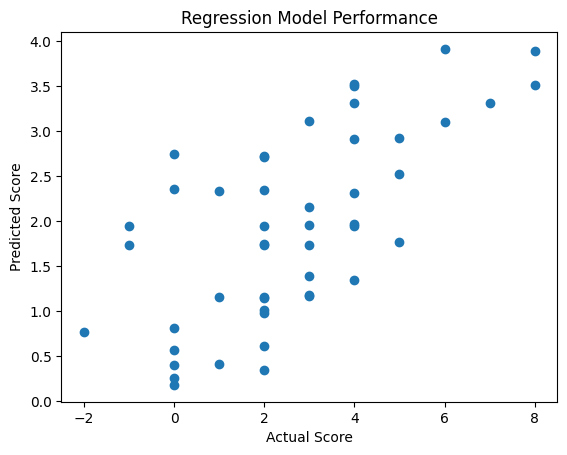

In [30]:
# Create visualization for data analysis
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Regression Model Performance")
plt.savefig("visualizations/regression_performance.png", bbox_inches="tight")
plt.show()


#### Summary of Analysis

In [31]:
print("Top Positive Employees")  #Top positive employees every month
print(top_positive)

print("\nTop Negative Employees")  #Top negative employees every month
print(top_negative)

print("\nFlight Risk Employees")
print(flight_risk)


Top Positive Employees
      employee_name    month  monthly_score
144   lydia.delgado  2010-01              4
168  patti.thompson  2010-01              4
48        eric.bass  2010-01              3
1     bobette.riner  2010-02              4
25     don.baughman  2010-02              4
..              ...      ...            ...
94      john.arnold  2011-11              4
190  patti.thompson  2011-11              4
143   kayne.coulter  2011-12              5
167   lydia.delgado  2011-12              4
191  patti.thompson  2011-12              4

[72 rows x 3 columns]

Top Negative Employees
     employee_name    month  monthly_score
0    bobette.riner  2010-01              0
72     john.arnold  2010-01              0
192  rhonda.denton  2010-01              0
73     john.arnold  2010-02             -1
121  kayne.coulter  2010-02             -1
..             ...      ...            ...
166  lydia.delgado  2011-11              0
70       eric.bass  2011-11              1
23   bobette.ri